In [142]:
#import libraries
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt
import sklearn as sk
import plotly.express as px
import scipy

np.set_printoptions(threshold=np.inf)



In [143]:
show_all = False  # change to True when you want to see everything

pd.set_option('display.max_rows', None if show_all else 10)


In [144]:
# import data
path = r'../data/online_retail_II.csv'
customer_df = pd.read_csv(path)
customer_df.columns = customer_df.columns.str.strip().str.lower().str.replace(' ', '_')
customer_df.head()

,invoice,stockcode,description,quantity,invoicedate,price,customer_id,country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [145]:
# basic understanding

# shape of the dataframe
print("Shape of Customer dataframe: ", customer_df.shape)
print('~~~~~~~~~ \n' '~~~~~~~~~')
print("Column data types: \n", customer_df.dtypes)
print('~~~~~~~~~ \n' '~~~~~~~~~')
print(customer_df.iloc[-1])
print('~~~~~~~~~ \n' '~~~~~~~~~')
print(customer_df.iloc[0])

Shape of Customer dataframe:  (1067371, 8)
~~~~~~~~~ 
~~~~~~~~~
Column data types: 
 invoice         object
stockcode       object
description     object
quantity         int64
invoicedate     object
price          float64
customer_id    float64
country         object
dtype: object
~~~~~~~~~ 
~~~~~~~~~
invoice                     581587
stockcode                     POST
description                POSTAGE
quantity                         1
invoicedate    2011-12-09 12:50:00
price                         18.0
customer_id                12680.0
country                     France
Name: 1067370, dtype: object
~~~~~~~~~ 
~~~~~~~~~
invoice                                     489434
stockcode                                    85048
description    15CM CHRISTMAS GLASS BALL 20 LIGHTS
quantity                                        12
invoicedate                    2009-12-01 07:45:00
price                                         6.95
customer_id                                13085.0
country  

In [146]:
# change datatypes
customer_df['invoicedate']=pd.to_datetime(customer_df['invoicedate'])
#customer_df['customer_id']=pd.to_numeric(customer_df['customer_id'])

In [147]:
#nulls check and drop
customer_df.isnull().sum()

invoice             0
stockcode           0
description      4382
quantity            0
invoicedate         0
price               0
customer_id    243007
country             0
dtype: int64

In [148]:
# nulll customer ids don't work, so we're dropping them
print(f'Rows before drops: {len(customer_df)}')
print(f'Null customer ids: {customer_df["customer_id"].isnull().sum()}')

# drop null customer ID
customer_df = customer_df.dropna(subset='customer_id')

print(f"Rows after drops: {len(customer_df)}")

Rows before drops: 1067371
Null customer ids: 243007
Rows after drops: 824364



 We found 243007 rows where customer_id is null, they have been dropped because we are looking to segment customers into different categories, registers that don't align to a specific customer are useless and likely wrong. now, what to do with null descriptions?

In [149]:
# investigate nulls descriptions
## have any of them been dropped alongide the null customer id? -- they were

customer_df.isnull().sum()

invoice        0
stockcode      0
description    0
quantity       0
invoicedate    0
price          0
customer_id    0
country        0
dtype: int64

In [150]:
# Check for negative quantites
print(f"Number of rows before drop: {len(customer_df)}")
print(f"Number of negative quantities: {len(customer_df[customer_df['quantity'] < 0])}")

# drop negative quantities because they probably represent returned or cancelled orders
# we only care about actually fulfilled orders

customer_df = customer_df[customer_df['quantity'] >= 0]
print(f"Rows after drop of negative numbers in quanitty: {len(customer_df)}")



Number of rows before drop: 824364
Number of negative quantities: 18744
Rows after drop of negative numbers in quanitty: 805620


In [151]:
# See if any other columns have negative numbers
customer_df.select_dtypes(include='number').columns[(customer_df.select_dtypes(include='number')<0).any()].to_list()


[]

In [152]:
print(f"Columns with negative values: {[col for col in customer_df.select_dtypes(include='number') if (customer_df[col]<0).any()]}")

Columns with negative values: []


In [153]:
## now i wanna check for any columns that have if any orders have price 0, and drop them because they represent free orders
## likely gifts of very heavily discounted columns
# Rows where the stockcode is M do not represent a real purchase, so i will be dropping them as well


print(f"Number of rows before drop: {len(customer_df)}")
print(f"Number of rows where stock code is M or order has price 0: {len(customer_df[(customer_df['stockcode']=='M') | (customer_df['price']==0)])}")
customer_df = customer_df[(customer_df['stockcode']!='M') & customer_df['price']!=0]
print(f"Number of rows after drop: {len(customer_df)}")

Number of rows before drop: 805620
Number of rows where stock code is M or order has price 0: 780
Number of rows after drop: 804840


In [154]:
## Now check for duplicates and drop them
print(f"Number of rows before dropping duplicates: {len(customer_df)}")
print(f"Number of duplicated rows: {customer_df.duplicated().sum()}")
customer_df=customer_df.drop_duplicates()
print(f"Number of rows after dropping duplicates: {len(customer_df)}")


Number of rows before dropping duplicates: 804840
Number of duplicated rows: 26096
Number of rows after dropping duplicates: 778744


In [155]:
## Double check datatypes
print("Column data types: \n", customer_df.dtypes)


Column data types: 
 invoice                object
stockcode              object
description            object
quantity                int64
invoicedate    datetime64[ns]
price                 float64
customer_id           float64
country                object
dtype: object


In [156]:
customer_df['customer_id'] = customer_df['customer_id'].astype(str)

### Distribution of Variables

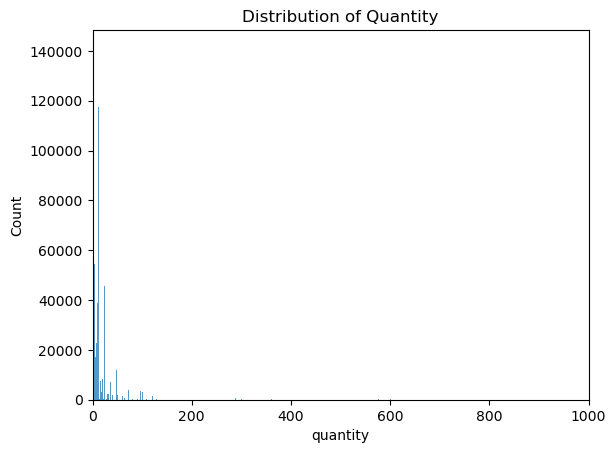

In [170]:
# Distribution of Quantity
sb.histplot(customer_df['quantity'], binwidth=1)
plt.xlim(0,1000)
plt.title('Distribution of Quantity')
plt.show()

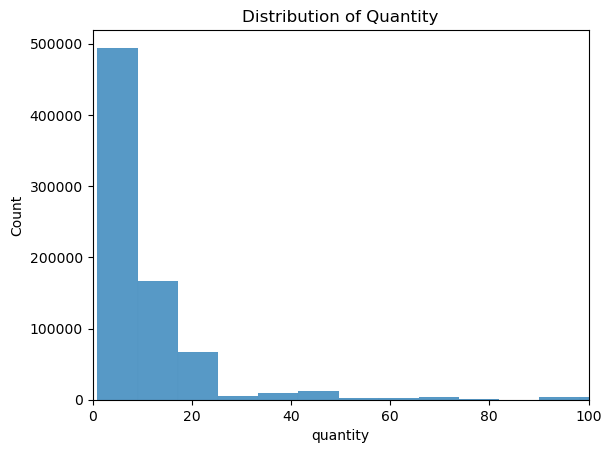

In [169]:
# Distribution of Quantity
sb.histplot(customer_df['quantity'], bins=10000)
plt.xlim(0,100)
plt.title('Distribution of Quantity')
plt.show()

In [165]:
customer_df['quantity'].describe()

count    778744.000000
mean         13.489116
std         145.894601
min           1.000000
25%           2.000000
50%           6.000000
75%          12.000000
max       80995.000000
Name: quantity, dtype: float64

Quantity is heavily right skewed, this means that most customer order in small quantities, 1-5 units
There are sharp spikes around round numbers: 1,2,5,10
Some outliers: Orders that involve quantities higher than 100, but very few

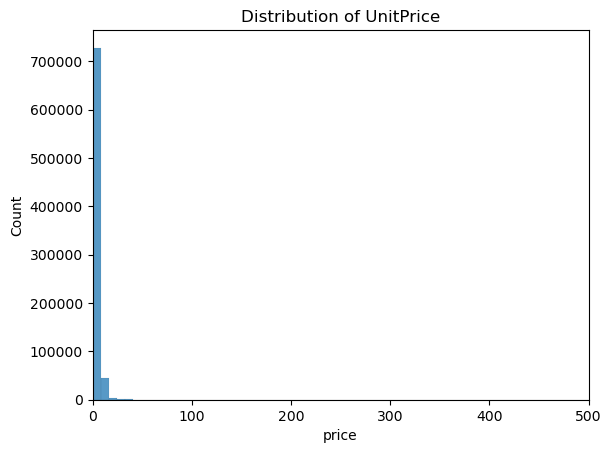

In [174]:
## Unit price distribution
sb.histplot(customer_df['price'], bins=1000)
plt.xlim(0, 500)
plt.title('Distribution of UnitPrice')
plt.show()